In [2]:
import scipy.io
import h5py

filename = 'Part_1.mat'

try:
    mat_data = scipy.io.loadmat(filename)
    print("Loaded successfully with scipy.io!")
    keys = [k for k in mat_data.keys() if not k.startswith('__')]
    print("Variables inside Part_1:", keys)
except NotImplementedError:
    print("v7.3 MATLAB file detected. Opening with h5py...")
    with h5py.File(filename, 'r') as f:
        print("Variables inside HDF5 container:", list(f.keys()))
        if 'p' in f:
            print("Shape of dataset 'p':", f['p'].shape)
except Exception as e:
    print("Error loading file:", e)

v7.3 MATLAB file detected. Opening with h5py...
Variables inside HDF5 container: ['#refs#', 'Part_1']


In [3]:
import h5py

filename = 'Part_1.mat'

with h5py.File(filename, 'r') as f:
    # Access the main Part_1 group
    part1_data = f['Part_1']
    print("Part_1 object type:", type(part1_data))
    print("Part_1 shape / length:", part1_data.shape)

    # Inspect the first patient/record array inside Part_1
    first_record_ref = part1_data[0][0]
    first_record = f[first_record_ref]
    print("First record array shape (channels x samples):", first_record.shape)

Part_1 object type: <class 'h5py._hl.dataset.Dataset'>
Part_1 shape / length: (3000, 1)
First record array shape (channels x samples): (61000, 3)


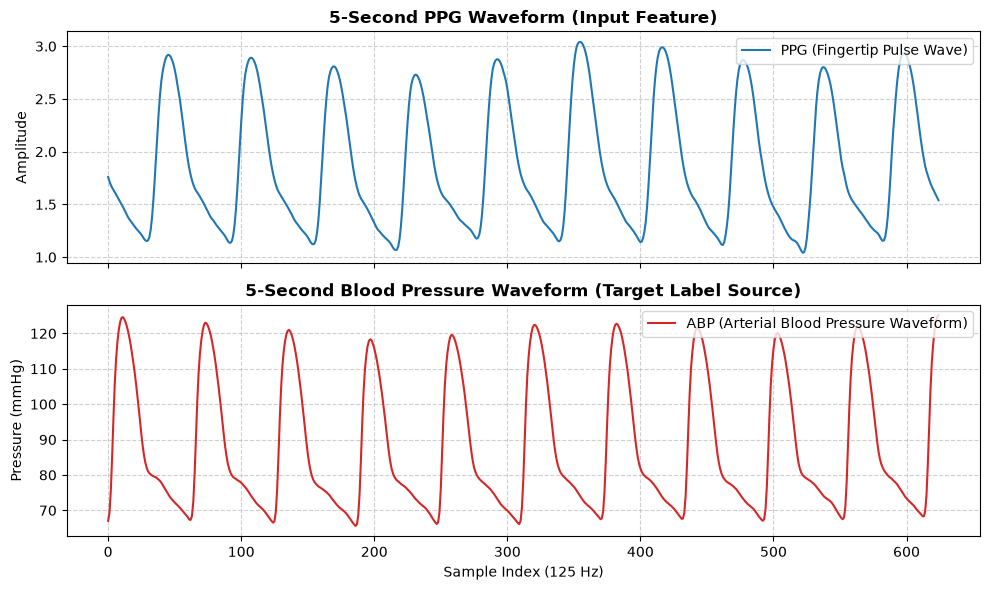

In [4]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Load 5-second PPG and ABP waveforms from Part_1.mat
with h5py.File('Part_1.mat', 'r') as f:
    first_record_ref = f['Part_1'][0][0]
    raw_signal = f[first_record_ref][:]  # (61000, 3)
    
    # 5-second slice (625 samples @ 125 Hz)
    ppg_window = raw_signal[:625, 0]
    abp_window = raw_signal[:625, 1]

# Create a side-by-side visual plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Plot PPG Signal
ax1.plot(ppg_window, color='#1f77b4', linewidth=1.5, label='PPG (Fingertip Pulse Wave)')
ax1.set_title("5-Second PPG Waveform (Input Feature)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Amplitude")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')

# Plot ABP Signal
ax2.plot(abp_window, color='#d62728', linewidth=1.5, label='ABP (Arterial Blood Pressure Waveform)')
ax2.set_title("5-Second Blood Pressure Waveform (Target Label Source)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Sample Index (125 Hz)")
ax2.set_ylabel("Pressure (mmHg)")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [5]:
import h5py
import pandas as pd

with h5py.File('Part_1.mat', 'r') as f:
    first_record_ref = f['Part_1'][0][0]
    raw_signal = f[first_record_ref][:]  # (61000, 3)

# Put the first 10 rows of numbers into a readable table
df = pd.DataFrame(raw_signal[:10, :2], columns=['PPG Signal', 'ABP (mmHg)'])
print(df)

   PPG Signal  ABP (mmHg)
0    1.759531   67.062955
1    1.718475   69.358628
2    1.684262   75.366453
3    1.657869   85.037586
4    1.637341   96.222885
5    1.615836  105.942862
6    1.593353  112.927569
7    1.570870  117.665447
8    1.549365  120.986846
9    1.526882  123.184831
